# Blood Atlas abundance coverage of the serum panel

## Scope

The Blood Atlas reports a circulating concentration per protein, measured by
mass spectrometry and by immunoassay. For the serum model these values are a
prior on the amount of enzyme present.

The specification prohibits writing an abundance value directly as an active
protease concentration $c_\pi$. A circulating protease can be a zymogen, an
inhibitor complex, or neither, and an abundance measurement counts all states
identically. The relation between abundance and activity is not a scaling
factor.

This notebook therefore reports coverage only: how many panel proteases have an
abundance value, how far the two methods differ, and how wide the range is.

## Inputs and outputs

Inputs: `raw/hpa/blood_ms_concentration.tsv.zip`,
`raw/hpa/blood_concentration_immunoassay.tsv.zip`, and the protease manifest.

Output: `results/0_03_hpa_abundance_coverage.csv` and
`results/0_03_hpa_abundance_per_protease.csv`.

In [1]:
import sys
import zipfile
from pathlib import Path

# The shared module sits one directory above the notebook; locating it by content
# keeps the notebooks working if the analysis directory is renamed or renumbered.
_cwd = Path.cwd().resolve()
_notebooks = next(p for p in [_cwd, *_cwd.parents] if (p / "_analysis_common.py").is_file())
sys.path.insert(0, str(_notebooks))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

import _analysis_common as common

common.apply_style()

## Parameters

Every knob this notebook has is in the cell below: thresholds, filters, sample
sizes and seeds. Shared policy that several notebooks obey — the assay-condition
window, the minimum evidence per protease, the permutation count — lives in
`_analysis_common.py` and is imported rather than repeated, so a change there
reaches every notebook that does not override it here.

In [2]:
HPA_ROOT = common.SERUM_RAW / "hpa"
MS_TABLE = HPA_ROOT / "blood_ms_concentration.tsv.zip"
IMMUNOASSAY_TABLE = HPA_ROOT / "blood_concentration_immunoassay.tsv.zip"

In [3]:
for path in (MS_TABLE, IMMUNOASSAY_TABLE):
    record = common.describe_source(path)
    print(f"{record['path']} | exists={record['exists']} | {record['bytes'] / 1e3:.0f} kB")

data/serum_proteolysis_calibration/raw/hpa/blood_ms_concentration.tsv.zip | exists=True | 39 kB
data/serum_proteolysis_calibration/raw/hpa/blood_concentration_immunoassay.tsv.zip | exists=True | 13 kB


In [4]:
def read_zipped_table(path: Path) -> pd.DataFrame:
    """Read the single TSV inside an HPA download archive.

    :param path: Zipped HPA table.
    :return: The table as distributed, column names unchanged.
    """

    with zipfile.ZipFile(path) as archive:
        inner_name = archive.namelist()[0]
        with archive.open(inner_name) as handle:
            return pd.read_csv(handle, sep="\t")


mass_spectrometry = read_zipped_table(MS_TABLE).rename(
    columns={"Gene": "gene", "ENSG ID": "ensembl_gene_id", "Conc [pg/L]": "concentration_pg_per_l"}
)
immunoassay = read_zipped_table(IMMUNOASSAY_TABLE).rename(
    columns={"conc [pg/L]": "concentration_pg_per_l", "sample type": "sample_type"}
)

manifest = common.load_serum_manifest()
included = manifest[manifest["include_in_hydrolysis_model"]].copy()
## The manifest stores transcript identifiers; the gene symbol is the join key HPA uses.
included["gene_key"] = included["gene_name"].str.upper()

print(f"HPA mass-spectrometry rows: {len(mass_spectrometry):,}")
print(f"HPA immunoassay rows:       {len(immunoassay):,}")
print(f"panel proteases to match:   {len(included)}")

HPA mass-spectrometry rows: 4,285
HPA immunoassay rows:       1,146
panel proteases to match:   54


In [5]:
ms_by_gene = (
    mass_spectrometry.assign(gene_key=mass_spectrometry["gene"].str.upper())
    .groupby("gene_key")["concentration_pg_per_l"]
    .median()
)
immunoassay_by_gene = (
    immunoassay.assign(gene_key=immunoassay["gene"].str.upper())
    .groupby("gene_key")["concentration_pg_per_l"]
    .median()
)

abundance = included[["merops_code", "merops_name", "gene_name", "gene_key", "serum_category"]].copy()
abundance["ms_pg_per_l"] = abundance["gene_key"].map(ms_by_gene)
abundance["immunoassay_pg_per_l"] = abundance["gene_key"].map(immunoassay_by_gene)
abundance["has_any_measurement"] = (
    abundance["ms_pg_per_l"].notna() | abundance["immunoassay_pg_per_l"].notna()
)

print(f"proteases with a gene symbol in the manifest: {int(abundance['gene_key'].ne('').sum())}")
print(f"  found in the mass-spectrometry table: {int(abundance['ms_pg_per_l'].notna().sum())}")
print(f"  found in the immunoassay table:       {int(abundance['immunoassay_pg_per_l'].notna().sum())}")
print(f"  found in at least one:                {int(abundance['has_any_measurement'].sum())} / {len(abundance)}")
print()
missing = abundance.query("not has_any_measurement")
print(f"no abundance measurement at all: {len(missing)}")
print(missing[["merops_code", "merops_name", "gene_name"]].head(15).to_string(index=False))

proteases with a gene symbol in the manifest: 51
  found in the mass-spectrometry table: 41
  found in the immunoassay table:       27
  found in at least one:                42 / 54

no abundance measurement at all: 12
merops_code                                      merops_name gene_name
    M10.006 matrix metallopeptidase-10 ({Homo sapiens}-type)     MMP10
    M10.009                       matrix metallopeptidase-12     MMP12
    M10.013                       matrix metallopeptidase-13     MMP13
    M14.004                               carboxypeptidase N          
    S01.015                                    tryptase beta          
    S01.135                                       granzyme A      GZMA
    S01.139                                       granzyme M      GZMM
    S01.143                                   tryptase alpha          
    S01.146                                       granzyme K      GZMK
    S01.147                                       granzyme H      GZMH

## Range of the values and agreement between methods

The two methods differ by orders of magnitude for part of the panel. A prior
built on these numbers has to represent that difference as uncertainty rather
than select one of the two tables.

In [6]:
both = abundance.dropna(subset=["ms_pg_per_l", "immunoassay_pg_per_l"]).copy()
both["log_ratio"] = np.log10(both["immunoassay_pg_per_l"] / both["ms_pg_per_l"])

print(f"proteases measured by both methods: {len(both)}")
if len(both):
    print(f"median |log10 ratio| between methods: {both['log_ratio'].abs().median():.2f} "
          f"(max {both['log_ratio'].abs().max():.2f})")
print()
measured = abundance[abundance["has_any_measurement"]].copy()
measured["best_estimate_pg_per_l"] = measured[["ms_pg_per_l", "immunoassay_pg_per_l"]].max(axis=1)
print("dynamic range across the measured panel:")
print(
    f"  min {measured['best_estimate_pg_per_l'].min():.3g} pg/L, "
    f"max {measured['best_estimate_pg_per_l'].max():.3g} pg/L "
    f"({np.log10(measured['best_estimate_pg_per_l'].max() / measured['best_estimate_pg_per_l'].min()):.1f} "
    f"orders of magnitude)"
)

proteases measured by both methods: 26
median |log10 ratio| between methods: 0.49 (max 4.00)

dynamic range across the measured panel:
  min 2.2e+03 pg/L, max 1.4e+11 pg/L (7.8 orders of magnitude)


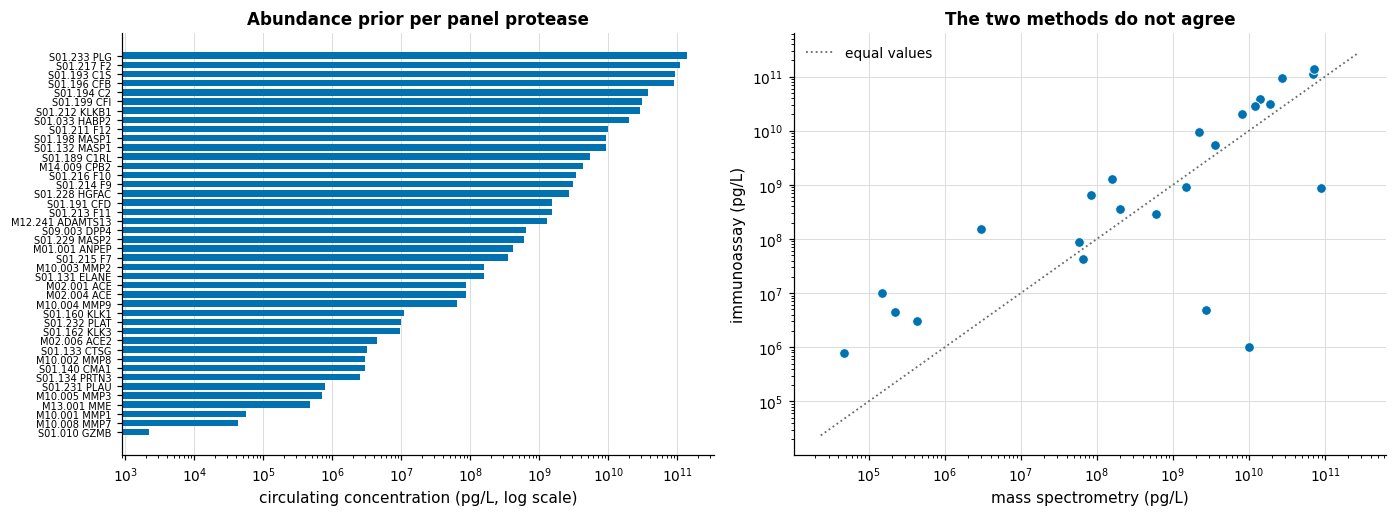

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12.8, 4.8))

ax = axes[0]
ordered = measured.sort_values("best_estimate_pg_per_l")
ax.barh(
    range(len(ordered)),
    ordered["best_estimate_pg_per_l"],
    color=common.CATEGORICAL_COLORS[0],
    height=0.7,
)
ax.set_yticks(range(len(ordered)))
ax.set_yticklabels([f"{row.merops_code} {row.gene_name}" for row in ordered.itertuples()], fontsize=6.5)
ax.set_xscale("log")
ax.set_xlabel("circulating concentration (pg/L, log scale)")
ax.set_title("Abundance prior per panel protease")
ax.grid(axis="y", visible=False)

ax = axes[1]
if len(both):
    ax.scatter(
        both["ms_pg_per_l"],
        both["immunoassay_pg_per_l"],
        s=40,
        color=common.CATEGORICAL_COLORS[0],
        edgecolor="white",
        linewidth=0.6,
    )
    limits = [
        min(both["ms_pg_per_l"].min(), both["immunoassay_pg_per_l"].min()) * 0.5,
        max(both["ms_pg_per_l"].max(), both["immunoassay_pg_per_l"].max()) * 2,
    ]
    ax.plot(limits, limits, color=common.NEUTRAL, linestyle=":", linewidth=1.2, label="equal values")
    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.set_xlabel("mass spectrometry (pg/L)")
    ax.set_ylabel("immunoassay (pg/L)")
    ax.set_title("The two methods do not agree")
    ax.legend()
fig.tight_layout()
plt.show()

## Coverage row

The row carries an explicit flag that the values are an abundance prior. Under
the deferred decisions of the specification, estimating individual active
concentrations stays out of scope until the earlier validations pass.

In [8]:
coverage = pd.DataFrame(
    [
        {
            "source": "hpa_blood_atlas",
            "measurement_type": "circulating_protein_concentration",
            "usable_as_active_concentration": False,
            "role": "abundance_prior_only",
            "n_panel_proteases": len(abundance),
            "n_with_mass_spectrometry": int(abundance["ms_pg_per_l"].notna().sum()),
            "n_with_immunoassay": int(abundance["immunoassay_pg_per_l"].notna().sum()),
            "n_with_any": int(abundance["has_any_measurement"].sum()),
            "n_with_both": len(both),
            "median_abs_log10_method_ratio": float(both["log_ratio"].abs().median()) if len(both) else np.nan,
            "verdict": "prior_only_not_a_label",
        }
    ]
)
common.save_result(abundance, "0_03_hpa_abundance_per_protease.csv")
destination = common.save_result(coverage, "0_03_hpa_abundance_coverage.csv")
print(f"written: {destination.relative_to(common.ROOT)}")
coverage.T

written: assets/experiments/analysis/09_26/20_serum_proteolysis_calibration_max/results/0_03_hpa_abundance_coverage.csv


,0
source,hpa_blood_atlas
measurement_type,circulating_protein_concentration
usable_as_active_concentration,False
role,abundance_prior_only
n_panel_proteases,54
n_with_mass_spectrometry,41
n_with_immunoassay,27
n_with_any,42
n_with_both,26
median_abs_log10_method_ratio,0.485387
